# 02 — SABR Implied Volatility

Reference: Hagan et al. (2002) formulas **(2.17a-c)** and the ATM limit **(2.18)**.

**SABR dynamics:**
$$ dF_t = \alpha_t F_t^\beta\,dW_1,\quad d\alpha_t = \nu\,\alpha_t\,dW_2,\quad dW_1\,dW_2 = \rho\,dt. $$

**Parameter meaning** (Slide 8 in the outline):

| Parameter | Effect |
|---|---|
| $\alpha$ | level of volatility (tied to ATM) |
| $\beta$  | backbone shape |
| $\rho$   | skew / slope |
| $\nu$    | smile curvature / vol-of-vol |

In [1]:
# allow importing from ../src
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.figsize': (7, 4.5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})


ATM (from 2.17 at K=F): 0.02022475
ATM (from 2.18      ): 0.02022475


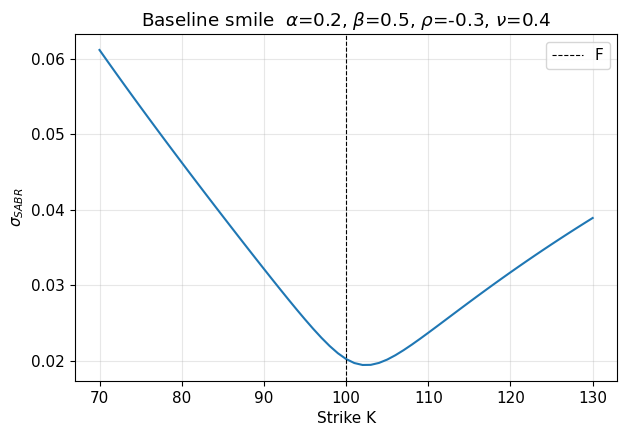

In [2]:
from src.sabr import sabr_vol, sabr_vol_atm

# reference set of SABR parameters (close to paper figure 3.3)
F0, T0 = 100.0, 1.0
alpha0, beta0, rho0, nu0 = 0.20, 0.5, -0.30, 0.40

Ks = np.linspace(70, 130, 61)
ivs = sabr_vol(Ks, F0, T0, alpha0, beta0, rho0, nu0)
print('ATM (from 2.17 at K=F):', float(sabr_vol(np.array([F0]), F0, T0, alpha0, beta0, rho0, nu0)[0]))
print('ATM (from 2.18      ):', sabr_vol_atm(F0, T0, alpha0, beta0, rho0, nu0))

plt.plot(Ks, ivs)
plt.axvline(F0, color='k', lw=0.8, ls='--', label='F')
plt.xlabel('Strike K'); plt.ylabel(r'$\sigma_{SABR}$')
plt.title(rf'Baseline smile  $\alpha$={alpha0}, $\beta$={beta0}, $\rho$={rho0}, $\nu$={nu0}')
plt.legend(); plt.show()

---
## Test — ATM consistency (2.17 at K=F must match 2.18)

In [3]:
for (a, b, r_, n) in [(0.1, 0.0, -0.3, 0.3),
                      (0.2, 0.5, -0.5, 0.4),
                      (0.3, 1.0,  0.0, 0.6)]:
    v_17 = float(sabr_vol(np.array([F0]), F0, T0, a, b, r_, n)[0])
    v_18 = sabr_vol_atm(F0, T0, a, b, r_, n)
    print(f'beta={b}  (2.17)={v_17:.8f}  (2.18)={v_18:.8f}  diff={abs(v_17-v_18):.2e}')

beta=0.0  (2.17)=0.00100649  (2.18)=0.00100649  diff=0.00e+00
beta=0.5  (2.17)=0.02015675  (2.18)=0.02015675  diff=0.00e+00
beta=1.0  (2.17)=0.30900000  (2.18)=0.30900000  diff=0.00e+00


---
## Sensitivity 1 — $\alpha$ (volatility level)

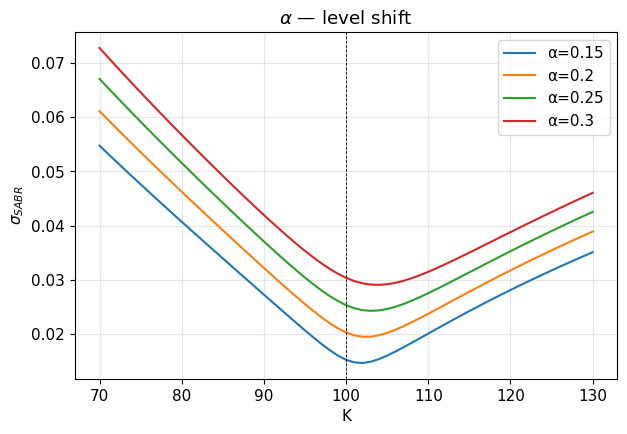

In [4]:
plt.figure()
for a in [0.15, 0.20, 0.25, 0.30]:
    plt.plot(Ks, sabr_vol(Ks, F0, T0, a, beta0, rho0, nu0), label=f'α={a}')
plt.axvline(F0, color='k', lw=0.6, ls='--')
plt.xlabel('K'); plt.ylabel(r'$\sigma_{SABR}$')
plt.title(r'$\alpha$ — level shift')
plt.legend(); plt.show()

---
## Sensitivity 2 — $\beta$ (backbone)

Compare **β ∈ {0, 0.5, 1}**, re-scaling α so that the ATM volatility is matched across β (apples-to-apples).

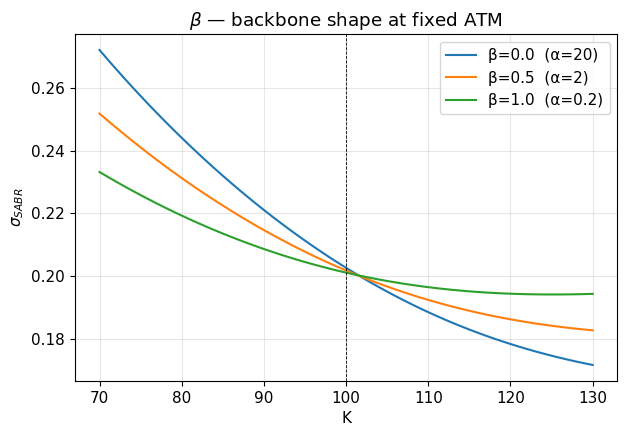

In [5]:
target_atm = 0.20
def alpha_for_atm(F, T, beta, rho, nu, atm):
    # solve alpha/F^(1-beta) * correction ≈ atm (1st-order use atm*F^(1-beta))
    return atm * F ** (1.0 - beta)

plt.figure()
for b in [0.0, 0.5, 1.0]:
    a = alpha_for_atm(F0, T0, b, rho0, nu0, target_atm)
    plt.plot(Ks, sabr_vol(Ks, F0, T0, a, b, rho0, nu0), label=f'β={b}  (α={a:.3g})')
plt.axvline(F0, color='k', lw=0.6, ls='--')
plt.xlabel('K'); plt.ylabel(r'$\sigma_{SABR}$')
plt.title(r'$\beta$ — backbone shape at fixed ATM')
plt.legend(); plt.show()

### β — backbone dynamics
As $F$ moves, ATM vol traces a backbone $\sigma_{ATM} \propto F^{\beta-1}$ (Hagan eq. 2.15). Plot ATM vol as $F$ varies:

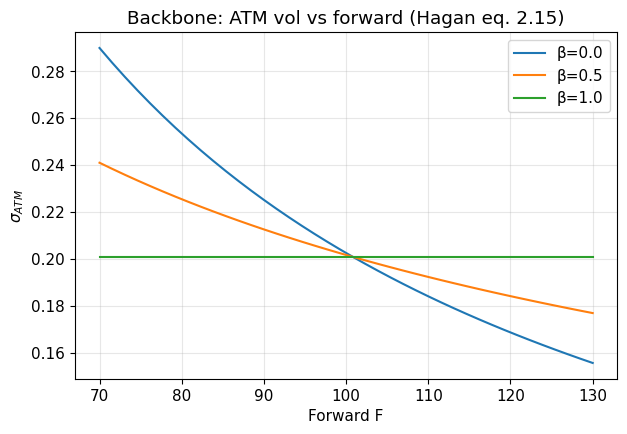

In [6]:
Fs = np.linspace(70, 130, 40)
plt.figure()
for b in [0.0, 0.5, 1.0]:
    a = alpha_for_atm(F0, T0, b, rho0, nu0, target_atm)
    atms = [sabr_vol_atm(f, T0, a, b, rho0, nu0) for f in Fs]
    plt.plot(Fs, atms, label=f'β={b}')
plt.xlabel('Forward F'); plt.ylabel(r'$\sigma_{ATM}$')
plt.title('Backbone: ATM vol vs forward (Hagan eq. 2.15)')
plt.legend(); plt.show()

**Observation.** β = 1 (lognormal) ⇒ ATM vol independent of F. β = 0 (normal) ⇒ ATM vol scales like $1/F$. β = 0.5 (CIR/bond-like) is intermediate.

---
## Sensitivity 3 — $\rho$ (skew)

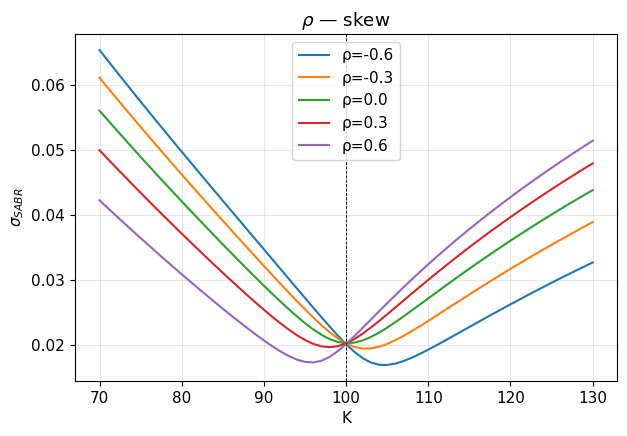

In [7]:
plt.figure()
for r_ in [-0.6, -0.3, 0.0, 0.3, 0.6]:
    plt.plot(Ks, sabr_vol(Ks, F0, T0, alpha0, beta0, r_, nu0), label=f'ρ={r_}')
plt.axvline(F0, color='k', lw=0.6, ls='--')
plt.xlabel('K'); plt.ylabel(r'$\sigma_{SABR}$')
plt.title(r'$\rho$ — skew')
plt.legend(); plt.show()

---
## Sensitivity 4 — $\nu$ (smile curvature)

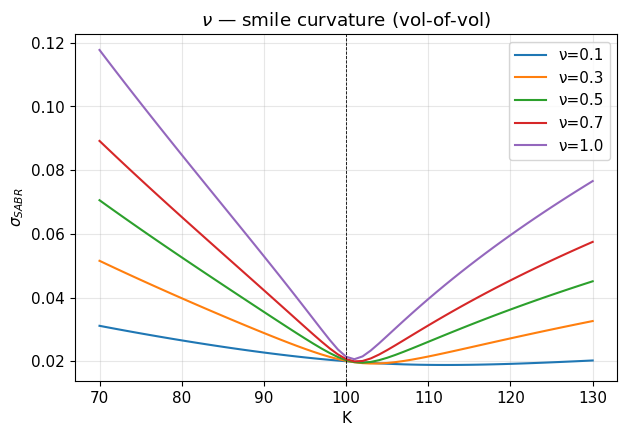

In [8]:
plt.figure()
for n in [0.1, 0.3, 0.5, 0.7, 1.0]:
    plt.plot(Ks, sabr_vol(Ks, F0, T0, alpha0, beta0, rho0, n), label=f'ν={n}')
plt.axvline(F0, color='k', lw=0.6, ls='--')
plt.xlabel('K'); plt.ylabel(r'$\sigma_{SABR}$')
plt.title(r'$\nu$ — smile curvature (vol-of-vol)')
plt.legend(); plt.show()

---
## Summary
* SABR implied-vol formula (Hagan 2.17a-c + 2.18 ATM) implemented.
* Consistency check: (2.17) at K=F equals (2.18) to machine precision.
* Sensitivity plots reproduce the qualitative descriptions on slide 8 of the outline:
  * $\alpha$ shifts the whole smile level
  * $\beta$ controls the backbone
  * $\rho$ controls the skew
  * $\nu$ controls the smile curvature
* Ready for Module 2 (sensitivity study) and Module 4 (market calibration).